# 02 — Baseline Models + MLflow Tracking
**Cybersecurity Intrusion Detection**

MOD10: Machine Learning — Winter 2026 — Concordia

---

## Objectifs
1. Entraîner 4 modèles baseline : **Dummy**, **Logistic Regression**, **Random Forest**, **XGBoost**
2. Logger chaque run dans MLflow (params, métriques, modèle, matrice de confusion)
3. Comparer les modèles sur 6 métriques : accuracy, precision, recall, F1, ROC-AUC, PR-AUC
4. Tracer ROC superposées + barplot F1 vs AUC
5. Choisir le champion baseline à battre par le DNN (notebook 03)

## Décisions
- **SMOTE désactivé** ici : on utilise `class_weight='balanced'` sur LR et RF, et `scale_pos_weight` sur XGBoost. Comparaison plus propre, et le dataset est équilibré (55/45).
- **Dummy Classifier** inclus comme plancher — on veut voir qu'on bat le "toujours prédire la classe majoritaire" (~55% accuracy).

In [1]:
# === Setup: paths + imports + seed ===
import os, sys, random, time, json
import warnings
warnings.filterwarnings('ignore')

# Run from repo root so `config/config.yaml`, `data/...`, `mlruns/` resolve
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
sys.path.insert(0, os.getcwd())

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
    confusion_matrix, classification_report,
)

import mlflow
import mlflow.sklearn

from src.utils.preprocessing import load_config, prepare_data

# Reproductibilité
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

FIGURES_DIR = 'reports/figures'
os.makedirs(FIGURES_DIR, exist_ok=True)

print(f'cwd = {os.getcwd()}')
print('Libraries loaded.')

cwd = C:\Users\Minos\Downloads\Cowork\Machine-learning\Projet\repo
Libraries loaded.


## 1. Chargement des données & pipeline preprocessing

On réutilise `prepare_data()` du module `src/utils/preprocessing.py` (même pipeline que le notebook 01, résultats reproductibles).

In [2]:
config = load_config('config/config.yaml')
X_train, X_test, y_train, y_test, preprocessor = prepare_data(config, apply_smote=False)

print(f'\nX_train: {X_train.shape} | X_test: {X_test.shape}')
print(f'y_train dist: {pd.Series(y_train).value_counts(normalize=True).round(3).to_dict()}')
print(f'y_test  dist: {pd.Series(y_test).value_counts(normalize=True).round(3).to_dict()}')

Dataset loaded: 9537 rows, 11 columns
Features engineered. New shape: (9537, 14)
Train: (7629, 18), Test: (1908, 18)

X_train: (7629, 18) | X_test: (1908, 18)
y_train dist: {0: 0.553, 1: 0.447}
y_test  dist: {0: 0.553, 1: 0.447}


## 2. MLflow — configuration de l'experiment

In [3]:
MLFLOW_TRACKING_URI = f'file:{os.path.abspath("mlruns")}'
EXPERIMENT_NAME = config['mlflow']['experiment_name']

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(EXPERIMENT_NAME)

print(f'Tracking URI : {MLFLOW_TRACKING_URI}')
print(f'Experiment   : {EXPERIMENT_NAME}')

2026/04/22 21:55:56 INFO mlflow.tracking.fluent: Experiment with name 'cybersecurity-ids' does not exist. Creating a new experiment.


Tracking URI : file:C:\Users\Minos\Downloads\Cowork\Machine-learning\Projet\repo\mlruns
Experiment   : cybersecurity-ids


## 3. Définition des modèles + helper de train/log

Helper inline (plutôt que `train_and_log_model` du module) pour logger explicitement :
- les 6 métriques (dont PR-AUC manquant dans le module)
- les temps d'entraînement et d'inférence
- la matrice de confusion en artifact
- le modèle sérialisé

In [4]:
# Modèles à benchmarker
MODELS = {
    'Dummy (most_frequent)': DummyClassifier(strategy='most_frequent', random_state=SEED),
    'Logistic Regression':   LogisticRegression(
        max_iter=config['models']['baselines']['logistic_regression']['max_iter'],
        class_weight=config['models']['baselines']['logistic_regression']['class_weight'],
        random_state=SEED,
    ),
    'Random Forest':         RandomForestClassifier(
        n_estimators=config['models']['baselines']['random_forest']['n_estimators'],
        max_depth=config['models']['baselines']['random_forest']['max_depth'],
        class_weight=config['models']['baselines']['random_forest']['class_weight'],
        random_state=SEED,
        n_jobs=-1,
    ),
    'XGBoost':               XGBClassifier(
        n_estimators=config['models']['baselines']['xgboost']['n_estimators'],
        max_depth=config['models']['baselines']['xgboost']['max_depth'],
        learning_rate=config['models']['baselines']['xgboost']['learning_rate'],
        scale_pos_weight=config['models']['baselines']['xgboost']['scale_pos_weight'],
        random_state=SEED,
        eval_metric='logloss',
        n_jobs=-1,
    ),
}

for name, model in MODELS.items():
    print(f'  - {name:25s} → {type(model).__name__}')

  - Dummy (most_frequent)     → DummyClassifier
  - Logistic Regression       → LogisticRegression
  - Random Forest             → RandomForestClassifier
  - XGBoost                   → XGBClassifier


In [5]:
def train_log_evaluate(name, model, X_tr, y_tr, X_te, y_te, figures_dir=FIGURES_DIR):
    """Entraîne, log MLflow, retourne métriques + predictions pour comparaison ultérieure."""
    with mlflow.start_run(run_name=name):
        # --- Training ---
        t0 = time.perf_counter()
        model.fit(X_tr, y_tr)
        train_time = time.perf_counter() - t0

        # --- Inference ---
        t0 = time.perf_counter()
        y_pred = model.predict(X_te)
        inference_time = time.perf_counter() - t0

        y_proba = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else None

        # --- Metrics ---
        metrics = {
            'accuracy':  accuracy_score(y_te, y_pred),
            'precision': precision_score(y_te, y_pred, zero_division=0),
            'recall':    recall_score(y_te, y_pred, zero_division=0),
            'f1_score':  f1_score(y_te, y_pred, zero_division=0),
            'train_time_s':     train_time,
            'inference_time_s': inference_time,
        }
        if y_proba is not None and len(np.unique(y_te)) > 1:
            metrics['roc_auc'] = roc_auc_score(y_te, y_proba)
            metrics['pr_auc']  = average_precision_score(y_te, y_proba)

        # --- Log params + metrics + model ---
        # get_params peut contenir des valeurs non-serialisables pour MLflow → on stringify
        safe_params = {k: str(v) for k, v in model.get_params().items()}
        mlflow.log_params(safe_params)
        mlflow.log_metrics(metrics)
        try:
            mlflow.sklearn.log_model(model, name.lower().replace(' ', '_').replace('(', '').replace(')', ''))
        except Exception as e:
            print(f'  [warn] log_model skipped for {name}: {e}')

        # --- Confusion matrix as artifact ---
        cm = confusion_matrix(y_te, y_pred)
        fig, ax = plt.subplots(figsize=(5, 4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=['Normal', 'Attack'],
                    yticklabels=['Normal', 'Attack'], ax=ax)
        ax.set_title(f'{name} — Confusion Matrix')
        ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
        plt.tight_layout()
        cm_path = os.path.join(figures_dir, f'cm_{name.lower().replace(" ", "_").replace("(", "").replace(")", "")}.png')
        fig.savefig(cm_path, dpi=140)
        mlflow.log_artifact(cm_path)
        plt.close(fig)

        # --- Summary line ---
        auc_str = f'{metrics.get("roc_auc", float("nan")):.4f}' if 'roc_auc' in metrics else 'N/A'
        print(f'[{name:25s}] acc={metrics["accuracy"]:.4f}  f1={metrics["f1_score"]:.4f}  '
              f'auc={auc_str}  train={train_time:.2f}s  infer={inference_time*1000:.1f}ms')

    return {'name': name, 'model': model, 'metrics': metrics,
            'y_pred': y_pred, 'y_proba': y_proba}

## 4. Boucle d'entraînement + logging

Les 4 modèles sont entraînés et loggés en séquence. Durée totale attendue sur ce dataset : < 1 minute.

In [6]:
results = []
for name, model in MODELS.items():
    r = train_log_evaluate(name, model, X_train, y_train, X_test, y_test)
    results.append(r)

print('\nDone. Lance `mlflow ui` depuis la racine du repo pour explorer les runs.')

2026/04/22 21:55:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/04/22 21:55:57 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026/04/22 21:56:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


[Dummy (most_frequent)    ] acc=0.5529  f1=0.0000  auc=0.5000  train=0.00s  infer=4.1ms


2026/04/22 21:56:05 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


...

2026/04/22 21:56:09 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[Random Forest            ] acc=0.8868  f1=0.8550  auc=0.8830  train=0.41s  infer=67.8ms


2026/04/22 21:56:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/04/22 21:56:13 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[XGBoost                  ] acc=0.8826  f1=0.8507  auc=0.8832  train=0.25s  infer=1.8ms

Done. Lance `mlflow ui` depuis la racine du repo pour explorer les runs.


## 5. Tableau comparatif

In [7]:
comparison = pd.DataFrame({r['name']: r['metrics'] for r in results}).T
comparison = comparison.round(4).sort_values('f1_score', ascending=False)
comparison

,accuracy,precision,recall,f1_score,train_time_s,inference_time_s,roc_auc,pr_auc
Random Forest,0.8868,1.0000,0.7468,0.8550,0.4052,0.0678,0.8830,0.9108
XGBoost,0.8826,0.9861,0.7479,0.8507,0.2466,0.0018,0.8832,0.9113
Logistic Regression,0.7573,0.7267,0.7327,0.7297,0.0207,0.0002,0.8164,0.8317
Dummy (most_frequent),0.5529,0.0000,0.0000,0.0000,0.0010,0.0041,0.5000,0.4471


In [8]:
# Classification report détaillé pour chaque modèle
for r in results:
    print(f'\n{"="*60}')
    print(f'  {r["name"]}')
    print("="*60)
    print(classification_report(y_test, r['y_pred'], target_names=['Normal', 'Attack'], zero_division=0))


  Dummy (most_frequent)
              precision    recall  f1-score   support

      Normal       0.55      1.00      0.71      1055
      Attack       0.00      0.00      0.00       853

    accuracy                           0.55      1908
   macro avg       0.28      0.50      0.36      1908
weighted avg       0.31      0.55      0.39      1908


  Logistic Regression
              precision    recall  f1-score   support

      Normal       0.78      0.78      0.78      1055
      Attack       0.73      0.73      0.73       853

    accuracy                           0.76      1908
   macro avg       0.75      0.75      0.75      1908
weighted avg       0.76      0.76      0.76      1908


  Random Forest
              precision    recall  f1-score   support

      Normal       0.83      1.00      0.91      1055
      Attack       1.00      0.75      0.86       853

    accuracy                           0.89      1908
   macro avg       0.92      0.87      0.88      1908
weighted 

## 6. Courbes ROC superposées

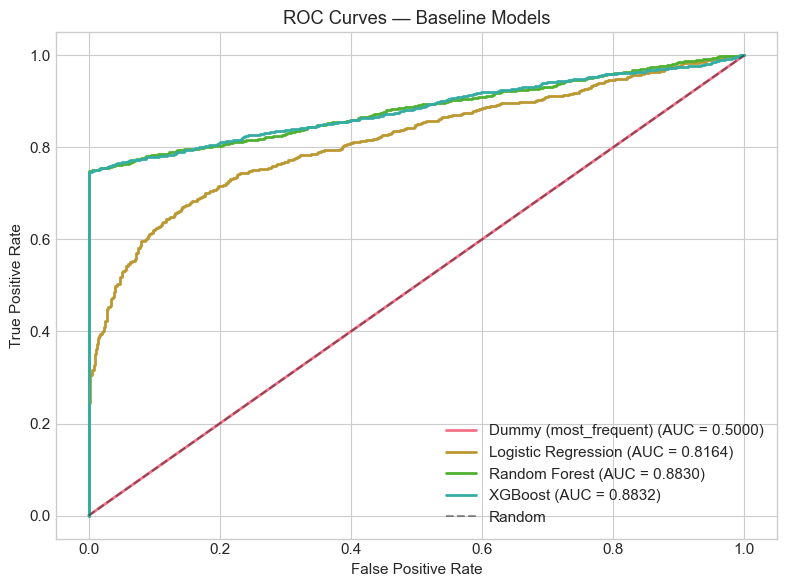

Saved: reports/figures\09_baselines_roc.png


In [9]:
fig, ax = plt.subplots(figsize=(8, 6))
for r in results:
    if r['y_proba'] is None:
        continue  # skip Dummy
    fpr, tpr, _ = roc_curve(y_test, r['y_proba'])
    auc = r['metrics'].get('roc_auc', float('nan'))
    ax.plot(fpr, tpr, label=f"{r['name']} (AUC = {auc:.4f})", linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Baseline Models')
ax.legend(loc='lower right')
plt.tight_layout()
roc_path = os.path.join(FIGURES_DIR, '09_baselines_roc.png')
fig.savefig(roc_path, dpi=140)
plt.show()
print(f'Saved: {roc_path}')

## 7. Barplot — F1 vs ROC-AUC

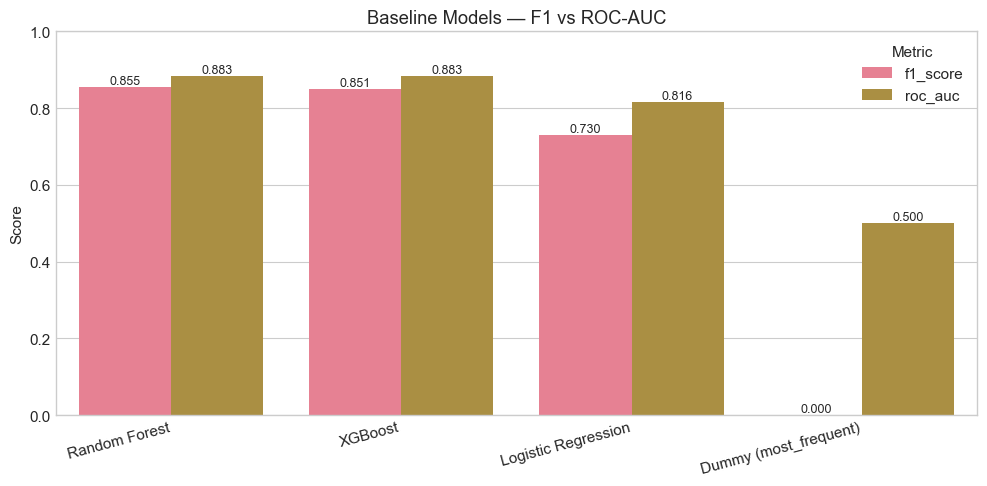

Saved: reports/figures\10_baselines_comparison.png


In [10]:
plot_df = comparison[['f1_score', 'roc_auc']].reset_index().rename(columns={'index': 'Model'})
plot_df_melt = plot_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=plot_df_melt, x='Model', y='Score', hue='Metric', ax=ax)
ax.set_title('Baseline Models — F1 vs ROC-AUC')
ax.set_ylim(0, 1)
ax.set_xlabel('')
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=9)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
bar_path = os.path.join(FIGURES_DIR, '10_baselines_comparison.png')
fig.savefig(bar_path, dpi=140)
plt.show()
print(f'Saved: {bar_path}')

## 8. Conclusion

**Champion baseline à battre par le DNN (notebook 03)** :

Voir le tableau ci-dessus — le modèle en tête sur **F1-score** (métrique la plus robuste en classification binaire légèrement déséquilibrée) est notre champion.

### À noter pour le rapport
- Le **Dummy Classifier** donne notre plancher réel (≈ 55% accuracy = fréquence de la classe majoritaire). Tout modèle en dessous serait cassé.
- La **Logistic Regression** ne peut capter que du signal linéaire → limitée par les corrélations Pearson vues au notebook 01 (`failed_logins` +0.36 est la plus forte).
- **Random Forest** et **XGBoost** exploitent les non-linéarités et les interactions → ils devraient dépasser LR de plusieurs points de F1.
- **XGBoost** est généralement le meilleur sur ce type de données tabulaires. Si notre DNN (notebook 03) n'arrive pas à le dépasser, on l'assume dans le rapport — c'est une conclusion légitime et pédagogique (les DNN ne sont pas magiques sur 9.5k samples tabulaires).

### Prochaines étapes
- **Notebook 03** : DNN avec Keras, comparaison au champion ci-dessus
- **Notebook 04** : SHAP sur le champion baseline + DNN
- **Notebook 05** : synthèse finale + choix du modèle à déployer via l'API

### Comment consulter les runs MLflow
```bash
# Depuis la racine du repo :
mlflow ui
# Ouvre http://127.0.0.1:5000
```